In [ ]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Saving model
import joblib

Load Dataset

In [ ]:
df = pd.read_csv("data.csv")

In [ ]:
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

(4600, 18)

Check Missing Values

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


Statistical Summary

In [ ]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


Correlation Heatmap

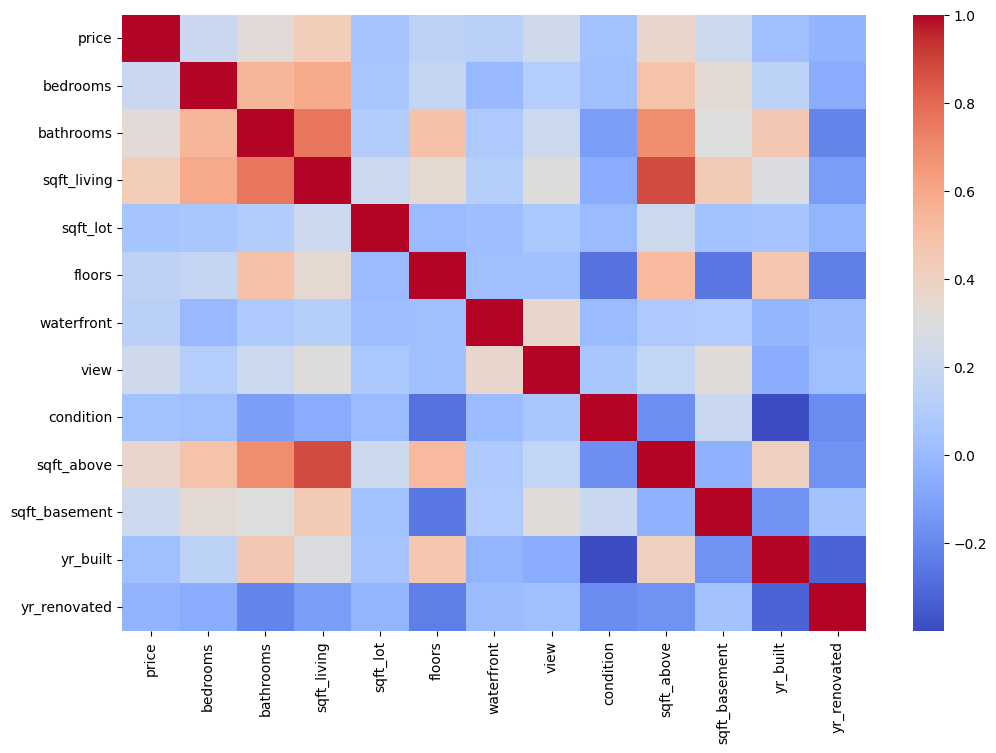

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

Distribution of Target Variable

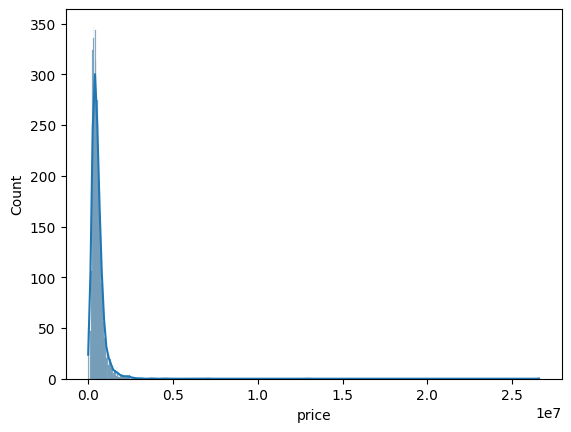

In [ ]:
sns.histplot(df['price'], kde=True)
plt.show()

Handle Missing Values

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_773/3551297251.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


For categorical columns:

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_773/2422164989.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Log Transformation

In [ ]:
df['price'] = np.log1p(df['price'])

Encode Categorical Variables

In [ ]:
df = pd.get_dummies(df, drop_first=True)

Feature Scaling

In [ ]:
scaler = StandardScaler()

Split Features and Target

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Scale the Data

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear Regression

In [ ]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

Random Forest Regressor

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

Gradient Boosting Regressor

In [ ]:
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

Evaluation Function

In [ ]:
def evaluate_model(y_true, y_pred, name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    print(f"{name}")
    print("MAE :", mae)
    print("RMSE:", rmse)
    print("R2  :", r2)
    print("-"*30)

Evaluate All Models

In [ ]:
evaluate_model(y_test, lr_pred, "Linear Regression")

evaluate_model(y_test, rf_pred, "Random Forest")

evaluate_model(y_test, gb_pred, "Gradient Boosting")

Linear Regression
MAE : 0.4166821306212235
RMSE: 1.370518641877244
R2  : 0.041745164602555174
------------------------------
Random Forest
MAE : 0.33098087096662404
RMSE: 1.3956374587595444
R2  : 0.006297552095474335
------------------------------
Gradient Boosting
MAE : 0.47551983447747687
RMSE: 1.3953938127846892
R2  : 0.00664447667331125
------------------------------


Residual Analysis

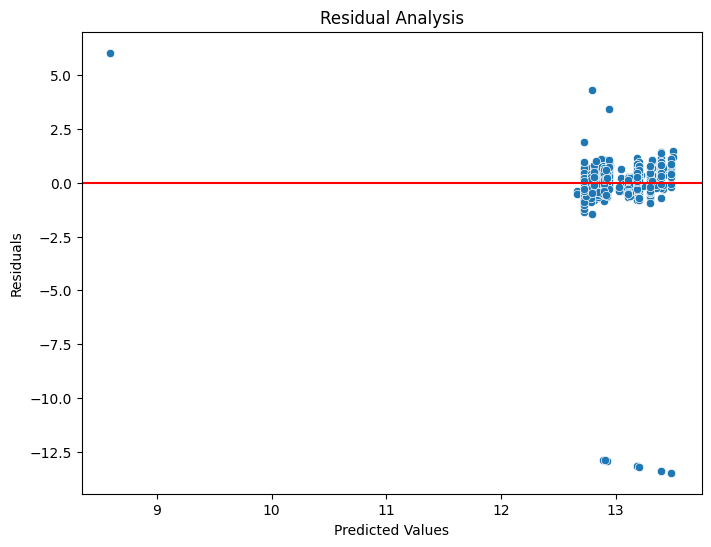

In [ ]:
residuals = y_test - gb_pred

plt.figure(figsize=(8,6))
sns.scatterplot(x=gb_pred, y=residuals)

plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()

Save the Best Model

In [ ]:
joblib.dump(gb, "house_price_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Load Model

In [ ]:
model = joblib.load("house_price_model.pkl")
scaler = joblib.load("scaler.pkl")

Prediction Cell

In [ ]:
sample_data = X_test.iloc[0:1]

prediction = gb.predict(sample_data)

print("Predicted House Price:", np.expm1(prediction[0]))

Predicted House Price: 367179.50071416836


In [33]:
import joblib

In [34]:
model

GradientBoostingRegressor(random_state=42)

In [35]:
joblib.dump(model, 'house_price_model.pkl')

['house_price_model.pkl']

In [36]:
StandardScaler()

StandardScaler()

In [37]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [38]:
loaded_model = joblib.load('house_price_model.pkl')